# Breast Cancer Survival Prediction

Bu projede Breast Cancer veri seti üzerinde çalışacağız ve hastaların verilerine göre kanser durumunu tahmin edeceğiz. Farklı makine öğrenmesi algoritmaları ve bir derin öğrenme modeli uygulayacağız.

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spam
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
import joblib
from sklearn.svm import SVC
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [59]:
df=pd.read_csv('BRCA.csv')

### EDA - Exploratory Data Analysis

Veriyi inceliyoruz; satır ve sütun sayısını, ayrıca sütunların yapısını gözlemliyoruz.

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341 entries, 0 to 340
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          334 non-null    object 
 1   Age                 334 non-null    float64
 2   Gender              334 non-null    object 
 3   Protein1            334 non-null    float64
 4   Protein2            334 non-null    float64
 5   Protein3            334 non-null    float64
 6   Protein4            334 non-null    float64
 7   Tumour_Stage        334 non-null    object 
 8   Histology           334 non-null    object 
 9   ER status           334 non-null    object 
 10  PR status           334 non-null    object 
 11  HER2 status         334 non-null    object 
 12  Surgery_type        334 non-null    object 
 13  Date_of_Surgery     334 non-null    object 
 14  Date_of_Last_Visit  317 non-null    object 
 15  Patient_Status      321 non-null    object 
dtypes: float

In [61]:
df.shape

(341, 16)

In [62]:
df.head()

,Patient_ID,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,TCGA-D8-A1XD,36.0,FEMALE,0.080353,0.42638,0.54715,0.273680,III,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy,15-Jan-17,19-Jun-17,Alive
1,TCGA-EW-A1OX,43.0,FEMALE,-0.420320,0.57807,0.61447,-0.031505,II,Mucinous Carcinoma,Positive,Positive,Negative,Lumpectomy,26-Apr-17,09-Nov-18,Dead
2,TCGA-A8-A079,69.0,FEMALE,0.213980,1.31140,-0.32747,-0.234260,III,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,08-Sep-17,09-Jun-18,Alive
3,TCGA-D8-A1XR,56.0,FEMALE,0.345090,-0.21147,-0.19304,0.124270,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy,25-Jan-17,12-Jul-17,Alive
4,TCGA-BH-A0BF,56.0,FEMALE,0.221550,1.90680,0.52045,-0.311990,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,06-May-17,27-Jun-19,Dead


In [63]:
df.describe()

,Age,Protein1,Protein2,Protein3,Protein4
count,334.000000,334.000000,334.000000,334.000000,334.000000
mean,58.886228,-0.029991,0.946896,-0.090204,0.009819
std,12.961212,0.563588,0.911637,0.585175,0.629055
min,29.000000,-2.340900,-0.978730,-1.627400,-2.025500
25%,49.000000,-0.358888,0.362173,-0.513748,-0.377090
50%,58.000000,0.006129,0.992805,-0.173180,0.041768
75%,68.000000,0.343598,1.627900,0.278353,0.425630
max,90.000000,1.593600,3.402200,2.193400,1.629900


Boş verileri kontrol ediyoruz ve görüldüğü üzere her sütunda eksik değerler var.

In [64]:
df.isnull().sum()

Patient_ID             7
Age                    7
Gender                 7
Protein1               7
Protein2               7
Protein3               7
Protein4               7
Tumour_Stage           7
Histology              7
ER status              7
PR status              7
HER2 status            7
Surgery_type           7
Date_of_Surgery        7
Date_of_Last_Visit    24
Patient_Status        20
dtype: int64

Bu eksik değerleri mode ve median ile dolduruyoruz. Verimizde boş değer olmamalı.

In [65]:
df['Date_of_Surgery']=pd.to_datetime(df['Date_of_Surgery'])

In [66]:
df['Date_of_Last_Visit']=pd.to_datetime(df['Date_of_Last_Visit'])

In [67]:
df['Date_of_Surgery']=df['Date_of_Surgery'].fillna(df['Date_of_Surgery'].median())

In [68]:
df['Date_of_Last_Visit']=df['Date_of_Last_Visit'].fillna(df['Date_of_Last_Visit'].median())

In [69]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [70]:
df['Protein1']=df['Protein1'].fillna(df['Protein1'].median())

In [71]:
df['Protein2']=df['Protein2'].fillna(df['Protein2'].median())

In [72]:
df['Protein3']=df['Protein3'].fillna(df['Protein3'].median())

In [73]:
df['Protein4']=df['Protein4'].fillna(df['Protein4'].median())

In [74]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])

In [75]:
df['Tumour_Stage']=df['Tumour_Stage'].fillna(df['Tumour_Stage'].mode()[0])

In [76]:
df['Histology']=df['Histology'].fillna(df['Histology'].mode()[0])

In [77]:
df['ER status']=df['ER status'].fillna(df['ER status'].mode()[0])

In [78]:
df['PR status']=df['PR status'].fillna(df['PR status'].mode()[0])

In [79]:
df['HER2 status']=df['HER2 status'].fillna(df['HER2 status'].mode()[0])

In [80]:
df['Surgery_type']=df['Surgery_type'].fillna(df['Surgery_type'].mode()[0])

In [81]:
df['Patient_Status']=df['Patient_Status'].fillna(df['Patient_Status'].mode()[0])

In [82]:
df['Patient_ID'] = df['Patient_ID'].fillna('Unknown')

In [83]:
df.isnull().sum()

Patient_ID            0
Age                   0
Gender                0
Protein1              0
Protein2              0
Protein3              0
Protein4              0
Tumour_Stage          0
Histology             0
ER status             0
PR status             0
HER2 status           0
Surgery_type          0
Date_of_Surgery       0
Date_of_Last_Visit    0
Patient_Status        0
dtype: int64

Seçtiğimiz sütunları grafiklerle görselleştiriyoruz.

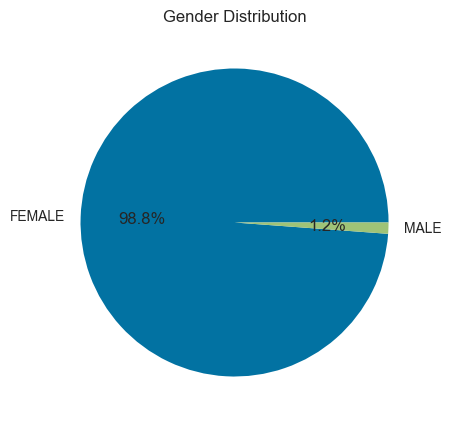

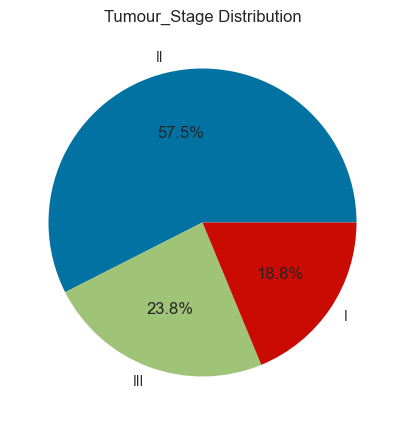

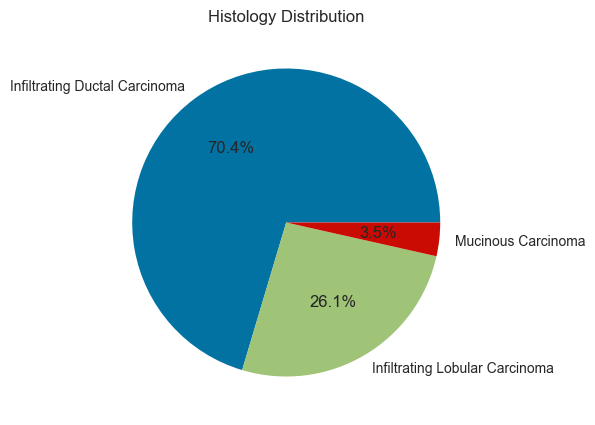

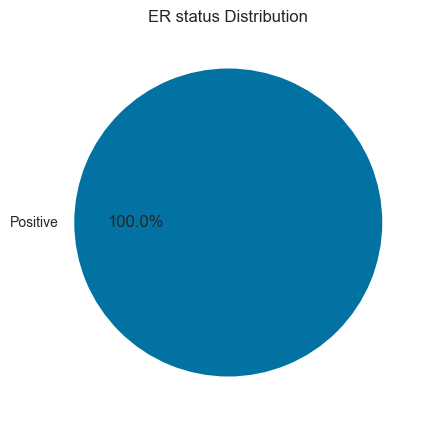

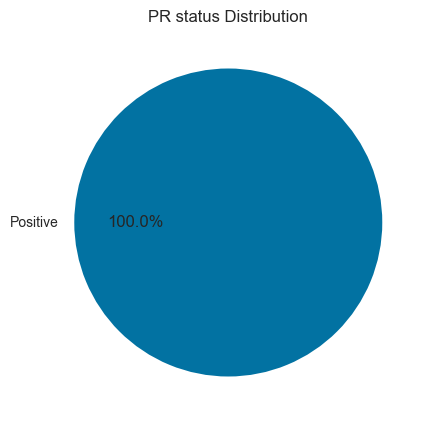

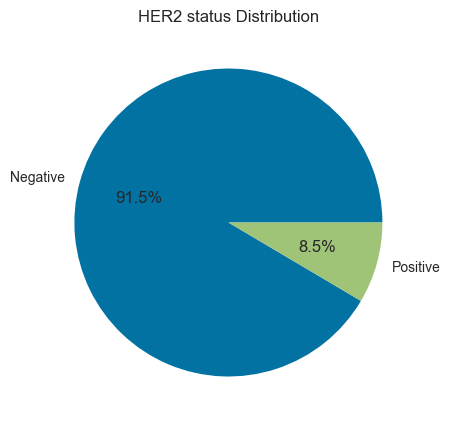

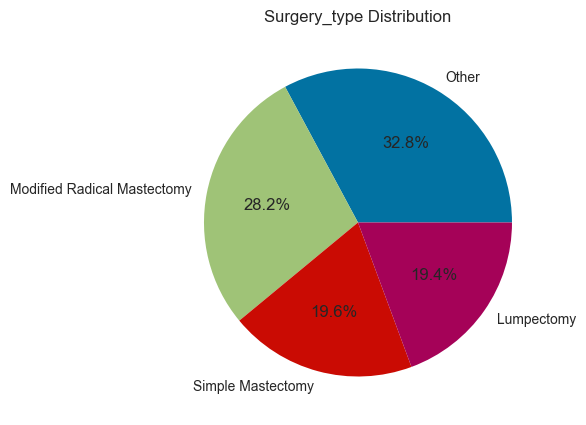

In [84]:
import matplotlib.pyplot as plt

columns = ['Gender', 'Tumour_Stage', 'Histology', 'ER status',
           'PR status', 'HER2 status', 'Surgery_type']

for col in columns:
    df[col].value_counts().head(5).plot(
        kind='pie',
        autopct='%1.1f%%',
        figsize=(5,5)
    )
    
    plt.title(col + " Distribution")
    plt.ylabel("")
    plt.show()

Kategorik sütunların içeriğine bakıyoruz, bunları sayısala çevirmemiz gerekiyor.

In [85]:
df['Tumour_Stage'].unique()

array(['III', 'II', 'I'], dtype=object)

In [86]:
df['Patient_Status'].unique()

array(['Alive', 'Dead'], dtype=object)

In [87]:
df['ER status'].unique()

array(['Positive'], dtype=object)

In [88]:
df['Gender'].unique()

array(['FEMALE', 'MALE'], dtype=object)

In [89]:
df['HER2 status'].unique()

array(['Negative', 'Positive'], dtype=object)

In [90]:
df['Surgery_type'].unique()

array(['Modified Radical Mastectomy', 'Lumpectomy', 'Other',
       'Simple Mastectomy'], dtype=object)

In [91]:
df['Histology'].unique()

array(['Infiltrating Ductal Carcinoma', 'Mucinous Carcinoma',
       'Infiltrating Lobular Carcinoma'], dtype=object)

Elimizdeki kategorik sütunları modelin kullanabilmesi için sayısal değerlere dönüştürüyoruz.

In [92]:
df["Patient_Status"].replace({"Alive":1, "Dead": 0}, inplace=True)

In [93]:
df["ER status"].replace({"Positive":1}, inplace=True)

In [94]:
df["PR status"].replace({"Positive":1}, inplace=True)

In [95]:
df["Tumour_Stage"].replace({'III':3, 'II':2, 'I':1}, inplace=True)

In [96]:
df["Gender"].replace({"FEMALE":1, "MALE": 0}, inplace=True)

In [97]:
df["HER2 status"].replace({"Negative":0, "Positive": 1}, inplace=True)

In [98]:
df["Surgery_type"].replace({'Modified Radical Mastectomy':0, 'Lumpectomy':2,'Simple Mastectomy':3,'Other':4}, inplace=True)

In [99]:
df["Histology"].replace({'Infiltrating Ductal Carcinoma':0, 'Mucinous Carcinoma':1,'Infiltrating Lobular Carcinoma':2}, inplace=True)

In [100]:
df.head()

,Patient_ID,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,TCGA-D8-A1XD,36.0,1,0.080353,0.42638,0.54715,0.273680,3,0,1,1,0,0,2017-01-15,2017-06-19,1
1,TCGA-EW-A1OX,43.0,1,-0.420320,0.57807,0.61447,-0.031505,2,1,1,1,0,2,2017-04-26,2018-11-09,0
2,TCGA-A8-A079,69.0,1,0.213980,1.31140,-0.32747,-0.234260,3,0,1,1,0,4,2017-09-08,2018-06-09,1
3,TCGA-D8-A1XR,56.0,1,0.345090,-0.21147,-0.19304,0.124270,2,0,1,1,0,0,2017-01-25,2017-07-12,1
4,TCGA-BH-A0BF,56.0,1,0.221550,1.90680,0.52045,-0.311990,2,0,1,1,0,4,2017-05-06,2019-06-27,0


### Model Training & Testing

X ve Y değişkenlerini belirliyoruz.

In [137]:
x = df[['Age', 'Gender', 'Protein1', 'Protein2', 'Protein3', 'Protein4','Tumour_Stage', 'Histology', 'ER status', 'PR status','HER2 status', 'Surgery_type']]
y = df['Patient_Status']

df.info()

In [153]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=.20, random_state=42)

Ve Linear Regressionla test etmeye başlıyoruz.

In [139]:
lr=LinearRegression()

In [140]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [141]:
tahmin=lr.predict(x_test)

In [142]:
r2_score(y_test,tahmin)

-0.25350788064138396

In [143]:
mean_squared_error(y_test,tahmin)**.5

0.4916270656632602

In [144]:
karsilastirma=pd.DataFrame()

In [145]:
karsilastirma['gercekfiyat']=y_test
karsilastirma['tahmin']=tahmin

In [146]:
karsilastirma

,gercekfiyat,tahmin
322,1,0.781251
116,0,0.787400
113,1,0.836027
42,1,0.834817
126,0,0.697880
...,...,...
173,1,0.836406
72,1,0.770224
75,1,0.755422
16,1,0.758017


In [148]:
print('Classification report for Linear Regression (Test set)= ')
tahmin_binary = (tahmin > 0.5).astype(int)
print(classification_report(y_test, tahmin_binary))

Classification report for Linear Regression (Test set)= 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.73      0.94      0.82        51

    accuracy                           0.70        69
   macro avg       0.36      0.47      0.41        69
weighted avg       0.54      0.70      0.61        69



Modelimizi kaydediyoruz.

In [149]:
joblib.dump(lr, 'linear_model.joblib')

['linear_model.joblib']

In [156]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def algo_test(x, y):
    algos = [
        LogisticRegression(max_iter=1000),
        RandomForestClassifier(),
        GradientBoostingClassifier(),
        AdaBoostClassifier(),
        DecisionTreeClassifier(),
        KNeighborsClassifier(),
        SVC(probability=True),
        MLPClassifier(max_iter=500)
    ]
    algo_names = [
        'Logistic Regression', 'Random Forest', 'Gradient Boosting',
        'AdaBoost', 'Decision Tree', 'KNN', 'SVC', 'MLP'
    ]

    x_scaled = MinMaxScaler().fit_transform(x)
    x_train, x_test, y_train, y_test = train_test_split(
        x_scaled, y, test_size=0.20, random_state=42
    )

    result = pd.DataFrame(columns=['Accuracy', 'F1 Score', 'ROC AUC'], index=algo_names)
    accuracies, f1s, aucs = [], [], []

    for algo in algos:
        algo.fit(x_train, y_train)
        y_pred = algo.predict(x_test)
        accuracies.append(accuracy_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_pred))

    result['Accuracy'] = accuracies
    result['F1 Score'] = f1s
    result['ROC AUC'] = aucs

    return result.sort_values('Accuracy', ascending=False)

In [157]:
algo_test(x,y)

,Accuracy,F1 Score,ROC AUC
Logistic Regression,0.739130,0.850000,0.500000
Random Forest,0.739130,0.850000,0.500000
SVC,0.739130,0.850000,0.500000
AdaBoost,0.724638,0.840336,0.490196
MLP,0.695652,0.820513,0.470588
KNN,0.695652,0.820513,0.470588
Gradient Boosting,0.681159,0.807018,0.478758
Decision Tree,0.521739,0.666667,0.406863


Genele bakacak olursak en iyi performansı Logistic Regression modelimiz veriyor. Accuracy değeri %73 lerde bizim için yeterli bir oran.

Burda da Derin Öğrenme ile tekrardan test ediyoruz.

In [158]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [172]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(x_train_scaled.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid')) 

model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy']        )
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 64)                  │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [173]:
history = model.fit(x_train_scaled, y_train, epochs=100, batch_size=64, validation_data=(x_test_scaled, y_test), verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.2721 - loss: 0.7896 - val_accuracy: 0.5362 - val_loss: 0.6948
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5037 - loss: 0.6994 - val_accuracy: 0.7391 - val_loss: 0.6444
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8051 - loss: 0.6241 - val_accuracy: 0.7391 - val_loss: 0.6119
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8199 - loss: 0.5654 - val_accuracy: 0.7391 - val_loss: 0.5942
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8235 - loss: 0.5264 - val_accuracy: 0.7391 - val_loss: 0.5886
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8235 - loss: 0.5136 - val_accuracy: 0.7391 - val_loss: 0.5901
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8235 - loss: 0.4878 - val_accuracy: 0.7391 - val_loss: 0.5991
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8235 - loss: 0.4882 - val_accuracy: 0.7391 - val_loss:

Derin öğrenme modelimiz klasik makine öğrenmesi modellerine göre daha yüksek accuracy elde etmiştir. % 82.3 lük accuracy bizim için oldukça ideal.

In [182]:
mean_squared_error(y_test,tahmin)**.5

0.4547686855027719

Bu modelide kaydediyoruz.

In [183]:
model.save('breast_cancer_model.h5')

Kısacası bu projede Breast Cancer veri seti üzerinde hastaların kanser olup olmadığını tahmin etmek için farklı makine öğrenmesi algoritmaları ve bir derin öğrenme modeli denedik. Modellerin performanslarını karşılaştırdık. Sonuçlarımıza göre derin öğrenme modeli accuracy: 0.82 ile klasik makine öğrenmesi modellerine göre daha iyi performans gösterdi.

tesekkürler :)